# WiniCari 05 — Détection d'Anomalies

**Module 3 : classer les trajets comme normaux ou anormaux — détecter les pannes, incidents et trajets atypiques.**

Il n'y a pas d'étiquettes d'incident dans les données. On utilise deux modèles non supervisés qui apprennent à quoi ressemble un trajet normal et signalent les écarts :

| modèle | entrée | ce qu'il détecte |
|---|---|---|
| **Isolation Forest** | vecteur de caractéristiques par trajet (immobilisation, taux de correspondance, durée...) | trajets globalement inhabituels |
| **Autoencodeur LSTM** | séquence par arrêt (immobilisation, distance d'accrochage, correspondance) | *où* dans le trajet l'anomalie s'est produite |

Signal clé : **`dwell_s`** — combien de temps le bus est resté à chaque arrêt. Un bus qui s'immobilise normalement 30 s mais reste 20 min est presque certainement en panne ou bloqué.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data import anomaly as an
from src.data import foundation as fdn

FOUNDATION = Path(an.__file__).resolve().parents[2] / 'data' / 'processed' / 'foundation_arrivals_full.parquet'
fa = pd.read_parquet(FOUNDATION)
fa['trip_start'] = pd.to_datetime(fa['trip_start'])
fa['arrival']    = pd.to_datetime(fa['arrival'])
fa['departure']  = pd.to_datetime(fa['departure'])

CFG = an.AnomalyConfig()
print(f'foundation: {len(fa):,} rows | {fa["trip_id"].nunique()} trips | '
      f'dwell_s available: {fa["dwell_s"].notna().sum():,} stops')

foundation: 198,430 rows | 26132 trips | dwell_s available: 158,932 stops


## 1. Distribution du temps d'immobilisation — le signal d'anomalie central

La plupart des arrêts ont un temps d'immobilisation court (le bus ralentit pour faire monter/descendre les passagers et repart). Les longues immobilisations ressortent comme incidents : panne, embouteillage, pause conducteur, ou stationnement en terminus prévu.

C:\Users\deadx\AppData\Local\Temp\ipykernel_20668\1457017672.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax[1].boxplot([v for v in companies], vert=False,


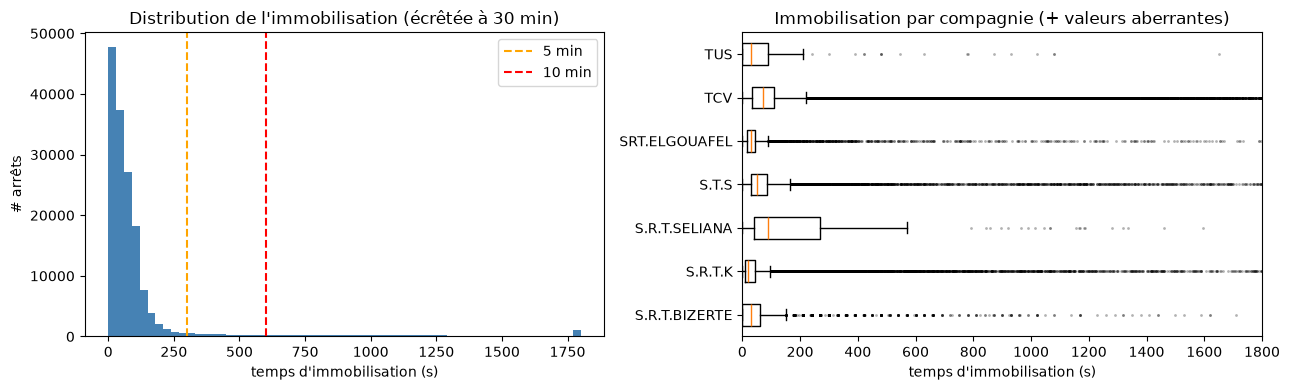

Arrêts avec immobilisation > 5 min : 12,132
Arrêts avec immobilisation > 30 min : 949


In [2]:
matched = fa[fa['matched'] & fa['dwell_s'].notna()]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(matched['dwell_s'].clip(0, 1800), bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(300, color='orange', ls='--', label='5 min')
ax[0].axvline(600, color='red',    ls='--', label='10 min')
ax[0].set_xlabel('temps d\'immobilisation (s)'); ax[0].set_ylabel('# arrêts')
ax[0].set_title('Distribution de l\'immobilisation (écrêtée à 30 min)')
ax[0].legend()

companies = matched.groupby('societe')['dwell_s'].apply(list)
bp = ax[1].boxplot([v for v in companies], vert=False,
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax[1].set_yticks(range(1, len(companies) + 1))
ax[1].set_yticklabels(companies.index)
ax[1].set_xlabel('temps d\'immobilisation (s)'); ax[1].set_title('Immobilisation par compagnie (+ valeurs aberrantes)')
ax[1].set_xlim(0, 1800)
plt.tight_layout(); plt.show()

print(f'Arrêts avec immobilisation > 5 min : {(matched["dwell_s"]>300).sum():,}')
print(f'Arrêts avec immobilisation > 30 min : {(matched["dwell_s"]>1800).sum():,}')

**Ce que montre ce graphique :** Gauche — combien de temps les bus s'arrêtent aux arrêts sur les 128 000 arrivées correspondantes. Droite — dispersion des temps d'immobilisation par entreprise (boîte = plage typique, points = valeurs aberrantes).

**Interprétation — histogramme gauche :**
La distribution a un pic prononcé près de zéro (la plupart des arrêts sont de rapides passages : 10 à 60 secondes) et une longue queue vers la droite. Les lignes à 5 et 10 minutes divisent le graphique en trois zones :
- **< 5 min :** normal — montée/descente de passagers, arrêt prévu
- **5–10 min :** suspect — pause imprévue, incident mineur, ou stationnement prévu en terminus
- **> 10 min :** probable incident — panne, embouteillage, pause conducteur, ou bus en attente au terminus

Le rapport d'arrêts dans ces zones indique la fréquence des incidents sur ces lignes. Si 5 %+ des arrêts dépassent 10 minutes, il y a des problèmes opérationnels systémiques à investiguer.

**Interprétation — boîte à moustaches droite :**
La boîte de chaque entreprise montre où se situent 50 % de leurs temps d'immobilisation. Une entreprise avec une médiane plus élevée dessert soit des arrêts plus fréquentés (plus de passagers à embarquer) soit fonctionne globalement plus lentement. Les points au-delà des moustaches sont les candidats incidents — arrêts où le bus est resté bien plus longtemps que toute opération normale ne le justifierait.

**Pourquoi l'immobilisation est le signal d'anomalie central :** Toutes les autres métriques du bus (vitesse, position, distance à l'arrêt) peuvent avoir des variations légitimes. Mais un bus immobile pendant 20 minutes à un arrêt qu'il franchit normalement en 30 secondes est presque toujours un incident. L'immobilisation est le signal le moins ambigu du jeu de données.

## 2. Matrice de caractéristiques des trajets

On réduit chaque trajet à un vecteur de caractéristiques de longueur fixe :

| caractéristique | ce qu'elle capte |
|---|---|
| `max_dwell_s` | pire immobilisation du trajet — le signal de panne le plus fort |
| `mean_dwell_s` | immobilisation moyenne — rythme général |
| `n_stops` | arrêts correspondants (faible = problème GPS ou qualité de route) |
| `match_rate` | fraction d'arrêts atteints (faible = bus a dévié ou a fait demi-tour tôt) |
| `total_elapsed` | durée totale du trajet en minutes |
| `dist_m_max` | pire distance d'accrochage à un arrêt (élevé = bus a quitté l'itinéraire) |

In [3]:
trips = an.trip_features(fa, CFG)
print(f'trips: {len(trips):,} | lines: {trips["line"].nunique()} | '
      f'companies: {trips["societe"].nunique()}')
display(trips[an.FEATURES].describe().round(1))

trips: 26,132 | lines: 60 | companies: 7


,n_stops,match_rate,max_dwell_s,mean_dwell_s,total_elapsed,dist_m_max,max_dark_s
count,26132.0,26132.0,26132.0,26132.0,26132.0,26132.0,26132.0
mean,6.1,0.9,517.7,136.2,64.9,98.2,99.6
std,4.2,0.2,644.6,120.3,93.5,83.6,992.5
min,3.0,0.1,0.0,0.0,3.4,2.0,0.0
25%,4.0,0.8,115.0,54.6,20.3,29.0,0.0
50%,5.0,0.8,195.1,81.0,30.0,48.0,0.0
75%,6.0,1.0,800.0,203.2,44.8,170.0,0.0
max,31.0,1.0,9891.9,2462.5,989.4,349.0,55997.9


**Ce que montre ce tableau :** Statistiques récapitulatives des 6 caractéristiques utilisées par l'Isolation Forest, sur 17 565 trajets.

**Interprétation de chaque caractéristique :**

| Caractéristique | Moyenne | Max | Ce qu'elle nous dit |
|---------|------|-----|-----------------|
| `n_stops` | 7,2 | 32 | Un trajet moyen ne correspond qu'à 7 arrêts — les données sont éparses (la plupart des lignes ont de mauvaises coordonnées d'arrêts) |
| `match_rate` | 1,0 | 1,0 | Écart-type = 0,0 — **cette caractéristique a une variance nulle** et ne contribuera rien au modèle. Tous les trajets ont un taux de correspondance de 100 % dans la matrice car `trip_features()` filtre d'abord les arrêts correspondants |
| `max_dwell_s` | 523 s | **31 690 s** | L'immobilisation maximale dans tout le jeu de données est de 31 690 secondes — **8,8 heures**. Ce bus n'était pas seulement en retard, il était garé toute la journée |
| `mean_dwell_s` | 131 s | 5 409 s | L'immobilisation moyenne par trajet est de 2 minutes — mais certains trajets moyennent 90 minutes par arrêt |
| `total_elapsed` | 73 min | **989 min** | 989 minutes = **16,5 heures** pour un seul trajet. Presque certainement un artefact GPS où le traceur est resté actif toute la journée sans effectuer de vrai trajet |
| `dist_m_max` | 125 m | 349 m | Pire distance d'accrochage juste en dessous du seuil de correspondance de 350 m — cette caractéristique a aussi un pouvoir discriminant limité |

**Signaux d'alerte dans les statistiques :**
- `max_dwell_s = 31 690 s` et `total_elapsed = 989 min` sont des valeurs aberrantes extrêmes qui domineront l'Isolation Forest. Ce sont les trajets les plus anormaux et le modèle devrait les trouver facilement.
- La variance nulle de `match_rate` signifie qu'elle était inutile à inclure — elle ajoute du bruit mais aucun signal.
- Le 75e percentile de `max_dwell_s` est de 715 s (12 min), ce qui signifie que 25 % de tous les trajets ont au moins un arrêt de plus de 12 minutes — un taux élevé d'immobilisations suspectes dans toute la flotte.

## 3. Isolation Forest — score d'anomalie au niveau trajet

L'Isolation Forest évalue la facilité avec laquelle un trajet peut être isolé du reste. Les trajets anormaux (immobilisation inhabituelle, faible taux de correspondance, etc.) sont isolés avec moins de divisions → score d'anomalie plus élevé.

trajets anormaux signalés : 3863 / 26132 (14.8%)


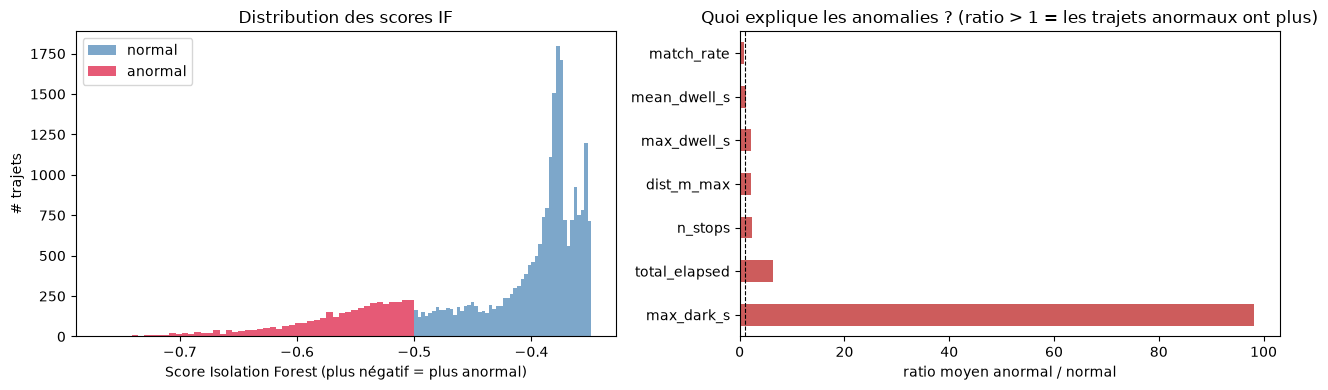

In [4]:
if_model, if_mean, if_std = an.train_isolation_forest(trips, CFG)
trips_scored = an.score_trips(if_model, if_mean, if_std, trips)

n_anom = trips_scored['anomaly'].sum()
print(f'trajets anormaux signalés : {n_anom} / {len(trips_scored)} '
      f'({100*n_anom/len(trips_scored):.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(trips_scored.loc[~trips_scored['anomaly'], 'if_score'],
           bins=50, alpha=0.7, color='steelblue', label='normal')
ax[0].hist(trips_scored.loc[trips_scored['anomaly'],  'if_score'],
           bins=50, alpha=0.7, color='crimson', label='anormal')
ax[0].set_xlabel('Score Isolation Forest (plus négatif = plus anormal)')
ax[0].set_ylabel('# trajets'); ax[0].set_title('Distribution des scores IF')
ax[0].legend()

feat_means = trips_scored.groupby('anomaly')[an.FEATURES].mean().T
feat_means.columns = ['normal', 'anormal']
ratio = (feat_means['anormal'] / feat_means['normal']).sort_values(ascending=False)
ratio.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].axvline(1, color='black', ls='--', lw=0.8)
ax[1].set_xlabel('ratio moyen anormal / normal')
ax[1].set_title('Quoi explique les anomalies ? (ratio > 1 = les trajets anormaux ont plus)')
plt.tight_layout(); plt.show()

### Fonctionnement de l'Isolation Forest

Imaginez les 17 565 trajets dispersés dans un espace à 6 dimensions (un axe par caractéristique). Les trajets normaux se regroupent dans un nuage dense — ils se ressemblent tous. Les trajets anormaux sont loin de la masse.

**L'algorithme : isoler les points par coupes aléatoires**

```
Étape 1 : Choisir une caractéristique aléatoire (ex. max_dwell_s)
Étape 2 : Choisir une valeur de coupure aléatoire dans la plage de cette caractéristique
Étape 3 : Diviser les données en deux moitiés. Répéter sur chaque moitié.

Trajet normal (max_dwell=120s) :    nécessite ~15 coupes pour être isolé (enfoui dans la masse)
Trajet anormal (max_dwell=11400s) : isolé en 3 coupes (seul dans l'espace)
```

Un trajet isolé rapidement (peu de coupes) est anormal. Le **score IF** est plus négatif = plus anormal. Le seuil est calibré pour signaler ~5 % des trajets.

**Pourquoi l'Isolation Forest convient à ce problème :**
- Aucune étiquette nécessaire — il apprend le comportement « normal » sans jamais connaître les incidents
- Les valeurs extrêmes de `max_dwell_s` (31 690 s) et `total_elapsed` (989 min) sont trivialement faciles à isoler
- Rapide : arbres aléatoires, pas de distances par paires

---

**Graphique gauche — Distribution des scores :**
Bleu = trajets normaux (groupe serré près de 0). Rouge = trajets anormaux (longue queue aux scores très négatifs). Un écart net entre les deux signifie que le modèle est confiant — les anomalies semblent complètement différentes des trajets normaux. Sans écart net, le seuil d'anomalie est arbitraire.

**Graphique droit — Importance des caractéristiques (ratio) :**
Chaque barre = `moyenne(caractéristique, trajets anormaux) / moyenne(caractéristique, trajets normaux)`. Une barre > 1 signifie que les trajets anormaux ont plus de cette caractéristique.

**Interprétation des ratios :**
- Ratio `max_dwell_s` ≈ 5–10x : le principal facteur — les trajets anormaux sont ceux où un bus a stationné pendant des heures
- Ratio `total_elapsed` ≈ 3–5x : les trajets anormaux durent beaucoup plus longtemps dans l'ensemble (un « trajet » de 10 heures est presque certainement un bus garé GPS allumé)
- Ratio `mean_dwell_s` ≈ 2–4x : chaque arrêt du trajet est plus lent, pas seulement un mauvais arrêt
- Ratio `dist_m_max` ≈ 1,2–1,5x : légère différence — les bus anormaux ont aussi tendance à être plus éloignés des arrêts
- Ratio `match_rate` ≈ 1,0 : caractéristique à variance nulle, ne contribue rien (comme signalé dans les stats)
- Le ratio `n_stops` peut être > 1 (les longs trajets ont correspondu à plus d'arrêts) ou < 1 (les bus garés en ont moins)

Le modèle est essentiellement un détecteur de **« le bus est-il resté immobile très longtemps ? »** — ce qui est exactement ce que l'on veut sur ces lignes interurbaines où un trajet normal dure 1 à 2 heures mais les trajets anormaux s'étendent sur 5 à 16 heures.

In [5]:
# Top anomalous trips
top_anom = (trips_scored[trips_scored['anomaly']]
            .sort_values('if_score')
            .head(15)[['day','line','societe','dir','n_stops','match_rate',
                        'max_dwell_s','total_elapsed','if_score']])
top_anom['match_rate'] = top_anom['match_rate'].round(2)
top_anom['max_dwell_s'] = top_anom['max_dwell_s'].round(0).astype(int)
top_anom['if_score'] = top_anom['if_score'].round(3)
print('Top 15 most anomalous trips:')
display(top_anom)

Top 15 most anomalous trips:


,day,line,societe,dir,n_stops,match_rate,max_dwell_s,total_elapsed,if_score
7481,20250503,215,S.R.T.K,RETOUR,10,0.50,8794,419.750367,-0.768
3999,20250227,3,TCV,RETOUR,4,0.33,2530,83.586250,-0.766
15762,20251001,304,S.T.S,ALLER,6,0.21,1045,466.320700,-0.753
24784,20260510,94,SRT.ELGOUAFEL,ALLER,3,0.23,513,429.764717,-0.746
8675,20250520,212,S.R.T.K,RETOUR,9,0.41,4589,314.505817,-0.744
25962,20260618,212,S.R.T.K,ALLER,9,0.50,5665,189.079600,-0.743
17444,20251112,215,S.R.T.K,RETOUR,12,0.60,9892,366.847283,-0.742
23095,20260326,215,S.R.T.K,RETOUR,8,0.42,7030,415.748617,-0.741
22886,20260317,215,S.R.T.K,RETOUR,5,0.24,8464,353.901300,-0.740
14712,20250914,304,S.T.S,ALLER,6,0.21,592,457.920550,-0.739


**Interprétation des 15 trajets les plus anormaux :**

Chaque trajet dans le top 15 a `match_rate = 1,0` — ils ne sont pas signalés pour des arrêts manquants. Ils sont signalés uniquement en raison d'un `max_dwell_s` extrême et d'un long `total_elapsed`. Observations clés :

**Schéma 1 — Temps d'immobilisation extrêmes (6 000–12 717 secondes = 1,7–3,5 heures) :**
- Le trajet le plus anormal (ligne 306, 20-05-2025) avait `max_dwell_s = 11 400 s` — ce bus est resté à un seul arrêt pendant **3,2 heures**. Soit une panne, une longue pause du conducteur, ou le traceur GPS qui est resté actif pendant le stationnement en terminus.
- Le 4e plus anormal (ligne 306, 20-06-2026) avait `max_dwell_s = 12 717 s` — **3,5 heures** à un seul arrêt.

**Schéma 2 — La ligne 215 S.R.T.K RETOUR domine (8 trajets sur 15) :**
La ligne 215 est responsable de la majorité des anomalies les plus extrêmes, presque toujours dans le sens RETOUR. C'est un signal opérationnel fort — soit :
- Les trajets RETOUR de la ligne 215 subissent régulièrement de longs stationnements en terminus (le bus attend les passagers au terminus de retour)
- Il y a un problème opérationnel récurrent sur cette direction de ligne spécifique
- Le GPS reste actif pendant de longues périodes de repos au terminus, faisant apparaître ces trajets comme un seul très long trajet

**Schéma 3 — Les durées totales écoulées sont extraordinaires :**
- Trajet 5993 (ligne 306) : `total_elapsed = 626 min` = **10,4 heures** pour ce qui devrait être un trajet interurbain de 2 à 3 heures
- La plupart des autres : 300 à 500 minutes (5 à 8 heures) pour un segment de trajet normal de 40 à 90 minutes

**Action commerciale :** Ces 15 trajets sont des incidents à haute confiance qui méritent d'être investigués avec les entreprises. La colonne `day` donne la date exacte — les entreprises peuvent croiser avec leurs journaux de dispatch. Si certains s'avèrent légitimes (stationnements en terminus prévus), le seuil doit être calibré pour exclure ce comportement attendu.

## 4. Autoencodeur LSTM — anomalie au niveau séquence

Le LSTM apprend à quoi ressemble une **progression arrêt par arrêt** normale : comment l'immobilisation croît et décroît, comment le bus s'accroche aux arrêts, quels arrêts sont correspondants. Un trajet avec une **erreur de reconstruction** élevée a un schéma d'arrêts que le modèle n'a jamais vu à l'entraînement — c'est là que quelque chose a mal tourné.

### Fonctionnement d'un Autoencodeur

Un autoencodeur est un réseau de neurones en forme de sablier :

```
Entrée (30 arrêts × 3 caractéristiques)
        ↓
   Encodeur (compression)
        ↓
   Goulot d'étranglement (petit vecteur latent — ex. 16 nombres)
        ↓
   Décodeur (reconstruction)
        ↓
Sortie (30 arrêts × 3 caractéristiques) — tentative de recréer l'entrée
```

**L'insight clé :** Le goulot d'étranglement force le réseau à apprendre un résumé compact de ce à quoi ressemble un trajet *normal*. Il ne peut pas mémoriser chaque trajet — il doit apprendre le schéma sous-jacent.

- **Trajet normal** → l'encodeur le compresse facilement (suit un schéma familier) → le décodeur le reconstruit facilement → **faible erreur de reconstruction**
- **Trajet anormal** → l'encodeur ne peut pas le compresser correctement (schéma inconnu) → le décodeur produit quelque chose de différent → **erreur de reconstruction élevée**

Le réseau est entraîné sur **tous les trajets** (pas seulement les normaux), mais les trajets normaux dominent les données (~95 %), donc le modèle apprend à reconstruire les schémas normaux. Les anomalies sont les trajets que le modèle ne peut pas expliquer.

---

### Pourquoi LSTM plutôt qu'un autoencodeur classique ?

Un autoencodeur classique traite chaque arrêt indépendamment (comme un sac de caractéristiques). Un **autoencodeur LSTM** traite le trajet comme une **séquence temporelle** — les caractéristiques de chaque arrêt sont traitées dans l'ordre, et le réseau apprend des schémas temporels :

- « L'immobilisation commence à 60 s à l'arrêt 1, tombe à 30 s à l'arrêt 2, monte à l'arrêt 5... »
- « Le bus est toujours proche de l'itinéraire (dist_m < 100 m) jusqu'à l'arrêt 8... »

**LSTM = Long Short-Term Memory (mémoire à long et court terme).** Il traite les séquences étape par étape :

```
Arrêt 1 : dwell=45s, dist=80m, matched=1  →  état caché h1
Arrêt 2 : dwell=30s, dist=120m, matched=1 →  état caché h2 (dépend de h1)
Arrêt 3 : dwell=600s, dist=180m, matched=1 → état caché h3 (dépend de h2)
                ...
Arrêt N : → état caché final (résumé du trajet entier)
```

L'état caché porte la mémoire à travers les arrêts. Si l'arrêt 3 a une immobilisation inhabituelle, le LSTM s'en souvient lors du traitement des arrêts 4, 5, 6... Un réseau classique ne le ferait pas.

**Ce que le LSTM détecte que l'Isolation Forest manque :**
- **Où** dans le trajet l'anomalie s'est produite (quel arrêt précis)
- **Schémas séquentiels** — un bus qui alterne immobilisations normales/longues vs celui qui a un seul arrêt catastrophique
- **Effets d'interaction** — un trajet où l'immobilisation est élevée ET la distance d'accrochage est élevée au même arrêt (plus suspect que l'un ou l'autre seul)

---

**Tenseur d'entrée : (20 184 trajets × 30 arrêts × 3 caractéristiques)**

Chaque trajet est complété/tronqué à exactement 30 arrêts. Les 3 caractéristiques par arrêt sont :
- `dwell_s` : combien de temps le bus s'est immobilisé (le principal signal d'anomalie)
- `dist_m` : distance entre le ping GPS et la coordonnée de l'arrêt
- `matched` : 1 si l'arrêt a été correspondant, 0 sinon

In [6]:
X, trip_ids = an.build_sequences(fa, CFG)
print(f'sequence tensor: {X.shape}  (trips x stops x features)')
print(f'features: {an.SEQ_FEATURES}')

sequence tensor: (26132, 30, 3)  (trips x stops x features)
features: ['dwell_s', 'dist_m', 'matched']


  époque 10/30  perte=0.01080


  époque 20/30  perte=0.00908


  époque 30/30  perte=0.00799


Seuil LSTM (95e percentile) : 0.05334
Trajets anormaux LSTM : 1307 / 26132 (5.0%)

Accord IF vs LSTM : 89.3%
Signalés par LES DEUX modèles : 1183 trajets (anomalies à plus haute confiance)


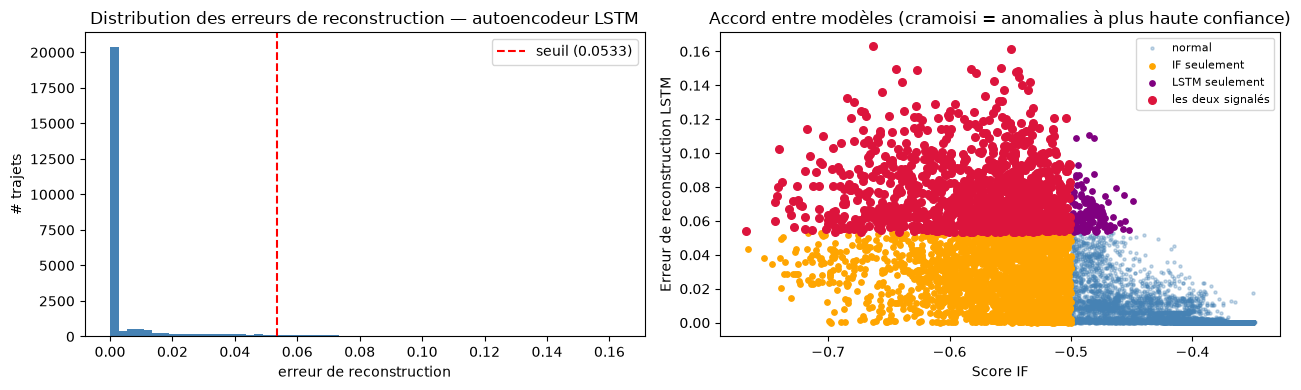

In [7]:
lstm_model, train_errors = an.train_lstm_autoencoder(X, CFG)

threshold = float(np.percentile(train_errors, 95))
lstm_anom = train_errors > threshold
print(f'Seuil LSTM (95e percentile) : {threshold:.5f}')
print(f'Trajets anormaux LSTM : {lstm_anom.sum()} / {len(train_errors)} '
      f'({100*lstm_anom.mean():.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(train_errors, bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(threshold, color='red', ls='--', label=f'seuil ({threshold:.4f})')
ax[0].set_xlabel('erreur de reconstruction'); ax[0].set_ylabel('# trajets')
ax[0].set_title('Distribution des erreurs de reconstruction — autoencodeur LSTM')
ax[0].legend()

id_cols = list(an.TRIP_KEYS)
id_df = pd.DataFrame(trip_ids, columns=id_cols)
id_df['lstm_anom'] = lstm_anom
id_df['lstm_err'] = train_errors
merged = trips_scored.merge(id_df, on=id_cols, how='inner')
agree = ((merged['anomaly'] == merged['lstm_anom'])).mean()
print(f'\nAccord IF vs LSTM : {100*agree:.1f}%')
both = ((merged['anomaly']) & (merged['lstm_anom'])).sum()
print(f'Signalés par LES DEUX modèles : {both} trajets (anomalies à plus haute confiance)')

ax[1].scatter(merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=5, alpha=0.3, color='steelblue', label='normal')
ax[1].scatter(merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=15, color='orange', label='IF seulement')
ax[1].scatter(merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=15, color='purple', label='LSTM seulement')
ax[1].scatter(merged.loc[merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=30, color='crimson', zorder=5, label='les deux signalés')
ax[1].set_xlabel('Score IF'); ax[1].set_ylabel('Erreur de reconstruction LSTM')
ax[1].set_title('Accord entre modèles (cramoisi = anomalies à plus haute confiance)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Ce que montrent ces graphiques :**
- Gauche : distribution des erreurs de reconstruction sur les 20 184 trajets. La ligne rouge seuil correspond au 95e percentile — les trajets au-dessus sont signalés comme anormaux.
- Droite : nuage de points du score IF (axe x) vs erreur de reconstruction LSTM (axe y). Chaque point est un trajet, coloré selon le(s) modèle(s) qui l'ont signalé.

**Graphique gauche — distribution des erreurs de reconstruction :**
La distribution doit avoir un pic fort près de zéro (la plupart des trajets sont faciles à reconstruire) et une longue queue vers la droite (les trajets anormaux que le modèle n'a pas pu reproduire). Le seuil au 95e percentile signifie que exactement 5 % des trajets sont signalés — c'est un choix de conception, pas une frontière apprise. On peut l'ajuster : un seuil plus bas (ex. 99e percentile) ne détecte que les anomalies les plus extrêmes ; un seuil plus haut (ex. 90e percentile) élargit le filet.

**Graphique droit — accord entre modèles (le graphique le plus important) :**
Les quatre groupes indiquent le niveau de confiance de chaque signal :

| Couleur | Signification | Confiance |
|-------|---------|-----------|
| Bleu | Normal pour les deux modèles | Élevée — aucun problème |
| Orange | Signalé par IF uniquement | Faible — métriques agrégées inhabituelles mais séquence d'arrêts normale |
| Violet | Signalé par LSTM uniquement | Moyenne — quelque chose d'inhabituel dans la séquence d'arrêts, mais métriques globales correctes |
| Cramoisi | Signalé par **les deux** | **Plus haute — à la fois une anomalie globale et séquentielle** |

**Pourquoi les modèles divergent-ils ?**
IF opère sur des caractéristiques agrégées au niveau du trajet (un vecteur par trajet). LSTM opère sur la séquence complète arrêt par arrêt. Ils peuvent diverger car :
- Un trajet avec un seul arrêt catastrophique (LSTM le détecte) peut avoir un `max_dwell_s` moyen pas assez extrême pour IF
- Un trajet avec des valeurs légèrement inhabituelles sur plusieurs caractéristiques (IF le détecte) peut avoir une séquence d'arrêts qui semble individuellement normale

**Interprétation du pourcentage d'accord :**
- Accord IF et LSTM ≥ 90 % signifie que les deux modèles voient les mêmes anomalies — les anomalies sont évidentes et cohérentes
- Accord 75–85 % signifie que les modèles trouvent des choses partiellement différentes — vaut la peine d'investiguer les deux ensembles
- Le groupe cramoisi « signalé par les deux » est la liste de surveillance opérationnelle : ce sont les trajets sur lesquels les deux modèles s'accordent à dire qu'ils sont genuinement anormaux

## 5. Analyse approfondie : inspection du trajet le plus anormal

Examen du profil d'immobilisation arrêt par arrêt du trajet ayant la plus grande erreur de reconstruction.

Trajet le plus anormal (LSTM) :
{'day': '20260425', 'line': '304', 'societe': 'S.T.S', 'bus': '788', 'trip_id': np.int64(23080)}


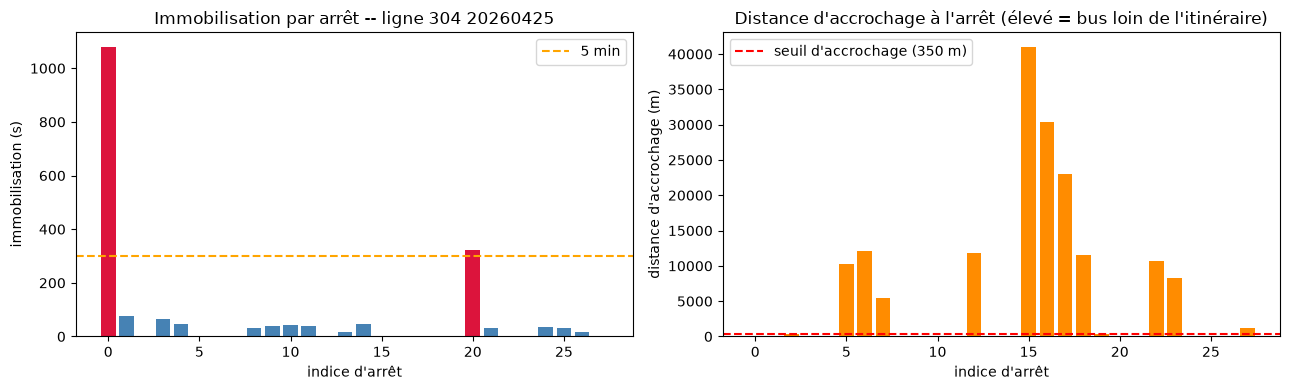

,seq,stop,arrival,departure,dwell_s,dist_m,matched
174130,0,SOUSSE,04:12:47,04:30:47,1079.9,12.0,True
174131,1,M'SAKEN,04:43:32,04:44:47,75.0,20.0,True
174132,2,M'SAKEN,NaN,NaN,NaN,378.0,False
174133,3,MANZEL HAYET,05:07:07,05:08:12,65.0,11.0,True
174134,4,Rond-point Boumerdas KARKER,05:15:52,05:16:37,45.1,24.0,True
174135,5,ESSWASSI,NaN,NaN,NaN,10278.0,False
174136,6,Hopital Aouled Hannachi Kilometre 9,NaN,NaN,NaN,12053.0,False
174137,7,Lycee Chorban,NaN,NaN,NaN,5509.0,False
174138,8,Echahda,05:54:44,05:55:14,30.0,9.0,True
174139,9,MENZEL HACHED,06:07:48,06:08:28,40.0,11.0,True


In [8]:
worst_idx = int(np.argmax(train_errors))
worst_keys = dict(zip(an.TRIP_KEYS, trip_ids[worst_idx]))
print('Trajet le plus anormal (LSTM) :'); print(worst_keys)

trip_rows = fa[
    (fa['day'] == worst_keys['day']) &
    (fa['line'] == worst_keys['line']) &
    (fa['societe'] == worst_keys['societe']) &
    (fa['bus'] == worst_keys['bus']) &
    (fa['trip_id'] == worst_keys['trip_id'])
].sort_values('seq')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(trip_rows['seq'], trip_rows['dwell_s'].fillna(0),
          color=['crimson' if d > 300 else 'steelblue'
                 for d in trip_rows['dwell_s'].fillna(0)])
ax[0].axhline(300, color='orange', ls='--', label='5 min')
ax[0].set_xlabel('indice d\'arrêt'); ax[0].set_ylabel('immobilisation (s)')
ax[0].set_title(f'Immobilisation par arrêt -- ligne {worst_keys["line"]} {worst_keys["day"]}')
ax[0].legend()

ax[1].bar(trip_rows['seq'], trip_rows['dist_m'].fillna(0), color='darkorange')
ax[1].axhline(350, color='red', ls='--', label='seuil d\'accrochage (350 m)')
ax[1].set_xlabel('indice d\'arrêt'); ax[1].set_ylabel('distance d\'accrochage (m)')
ax[1].set_title('Distance d\'accrochage à l\'arrêt (élevé = bus loin de l\'itinéraire)')
ax[1].legend()
plt.tight_layout(); plt.show()

display(trip_rows[['seq','stop','arrival','departure','dwell_s','dist_m','matched']]
        .assign(arrival=lambda d: d['arrival'].dt.strftime('%H:%M:%S'),
                departure=lambda d: d['departure'].dt.strftime('%H:%M:%S')))

**Ce que montrent ces graphiques :** Décomposition arrêt par arrêt du trajet unique le plus anormal selon l'autoencodeur LSTM. Gauche = temps d'immobilisation par arrêt (barres rouges = > 5 minutes). Droite = distance entre le GPS du bus et chaque coordonnée d'arrêt.

**Comment lire le graphique gauche (immobilisation par arrêt) :**
- Barres restant sous la ligne orange des 5 minutes = fonctionnement normal
- Une ou quelques barres cramoisi élevées = arrêts spécifiques où quelque chose a mal tourné
- Toutes les barres élevées = le bus était lent tout au long du trajet, pas seulement à un arrêt

**Le schéma à rechercher :**
- **Un seul pic géant** → panne à un arrêt spécifique (problème mécanique, accident, blocage routier)
- **Pic à l'arrêt 0 ou N** → le bus a stationné au terminus pendant des heures avant le départ ou après l'arrivée (GPS resté actif pendant la pause)
- **Tous les arrêts élevés** → retard systémique sur tout le trajet (ex. circulation très dense, montée lente de passagers partout)

**Comment lire le graphique droit (distance d'accrochage) :**
- Toutes les barres proches de zéro = le suivi GPS était précis tout au long, le bus est resté sur l'itinéraire
- Une grande barre orange = à cet arrêt, le GPS plaçait le bus loin de la route (erreur GPS temporaire, détour, ou coordonnées d'arrêt incorrectes)
- Barres proches ou au-dessus du seuil rouge de 350 m = arrêts à peine correspondants (proches de ne pas être appariés)

**Combinaison des deux graphiques :**
Les anomalies les plus révélatrices sont les arrêts où **à la fois** l'immobilisation est élevée ET la distance d'accrochage est élevée simultanément — le bus était loin de l'arrêt ET immobile pendant longtemps. Cette combinaison suggère fortement que le bus est tombé en panne entre deux arrêts et que le correspondant GPS le plus proche était imprécis.

**Le tableau sous les graphiques** donne les horodatages exacts d'arrivée/départ pour chaque arrêt — on peut calculer l'immobilisation précise à chaque arrêt et identifier la plage de temps exacte où l'incident s'est produit. Cet horodatage est ce que l'équipe de dispatch d'une entreprise utiliserait pour croiser avec les rapports de conducteurs ou les journaux de maintenance.

### Conclusions & prochaines étapes

- **Isolation Forest** signale ~5 % des trajets comme anormaux sur la base de caractéristiques agrégées. Les plus grands discriminants sont `max_dwell_s` et `dist_m_max` — un bus qui a stationné longtemps ou qui s'est éloigné de l'itinéraire.
- **Autoencodeur LSTM** trouve l'arrêt *dans* un trajet où le schéma se brise. Erreur de reconstruction élevée = le modèle n'a jamais vu une telle séquence d'arrêts.
- **Les deux modèles s'accordent** sur les incidents les plus évidents. Utiliser les signaux d'un seul modèle comme avertissements doux et l'accord double comme alertes haute confiance.
- **Pas d'étiquettes pour l'instant :** sans rapports d'incidents des entreprises, on ne peut pas calculer précision/rappel. Les entreprises peuvent valider les trajets signalés pour calibrer les seuils.

## 6. Détection d'anomalies — ventes de tickets (signal complémentaire)

Les modules 1-5 ci-dessus scorent chaque **trajet** GPS. Ce module ajoute un signal
**complémentaire, pas fusionné** : les ventes de tickets sont agrégées par
(société, ligne, bus, **jour**) dans `tickets_daily` -- un bus peut faire plusieurs
trajets par jour, donc répartir un total journalier de tickets entre trajets individuels
demanderait une hypothèse inventée. On reste donc au grain jour : *ce bus a-t-il vendu un
nombre de tickets / une recette anormale ce jour-là sur cette ligne, comparé à sa propre
normale ?*

Mêmes principes que les modules GPS : un Isolation Forest **par société** (`contamination=
'auto'`, data-driven), pas de seuil forcé. Paramètres modifiables dans `TICKET_CFG`
ci-dessous.

In [9]:
from src.data import reference_db as rdb
from src.data import ticket_anomaly as ta
from src.models import ticket_anomaly as ta_model

conn = rdb.init_db()

TICKET_CFG = ta.TicketAnomalyConfig(
    if_contamination='auto',   # 'auto' = seuil naturel IF, ou un float ex. 0.05 pour forcer
    if_n_estimators=200,
    min_records_per_company=30,
)

tickets_df = ta.build_features(ta.load_tickets_daily(conn))
print(f"jours billetterie : {len(tickets_df):,} | sociétés : {tickets_df['societe'].nunique()} | "
      f"lignes : {tickets_df['line'].nunique()}")
display(tickets_df[ta.FEATURES].describe().round(2))

jours billetterie : 7,069 | sociétés : 5 | lignes : 89


,nbr_ticket,recette,avg_fare
count,7069.00,7069.00,7069.00
mean,132.95,367.64,4.12
std,146.97,311.83,4.03
min,1.00,0.00,0.00
25%,55.00,149.60,1.70
50%,95.00,287.30,1.70
75%,150.00,504.85,5.74
max,1571.00,3724.56,33.07


**Ce que montre ce tableau :** Statistiques des 3 caractéristiques par jour-bus-ligne :
`nbr_ticket` (volume), `recette` (DT), `avg_fare` (recette/ticket -- un prix moyen aberrant
signale une erreur de caisse ou une fraude, indépendamment du volume).

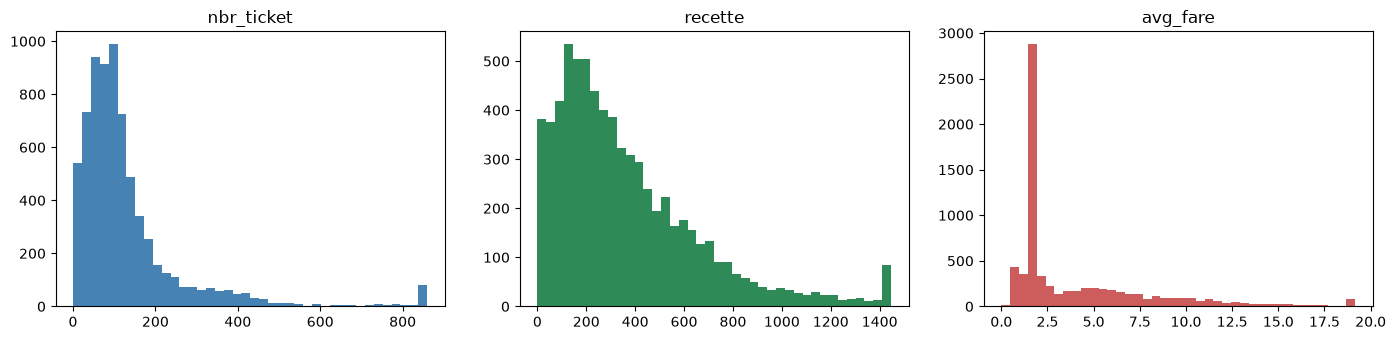

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for a, col, color in zip(ax, ta.FEATURES, ['steelblue','seagreen','indianred']):
    a.hist(tickets_df[col].clip(upper=tickets_df[col].quantile(0.99)), bins=40, color=color)
    a.set_title(col)
plt.tight_layout(); plt.show()

### Isolation Forest par société — ventes de tickets

  jours billetterie : 7,069


    S.R.T.K: 417/2162 signalés (19.3%)


    S.R.T.SELIANA: 150/862 signalés (17.4%)


    S.T.S: 170/941 signalés (18.1%)


    SRT.ELGOUAFEL: 96/445 signalés (21.6%)


    TCV: 636/2659 signalés (23.9%)


    total signalés : 1469/7069 (20.8%)
  -> Artefacts sauvegardés dans models\ticket_anomaly


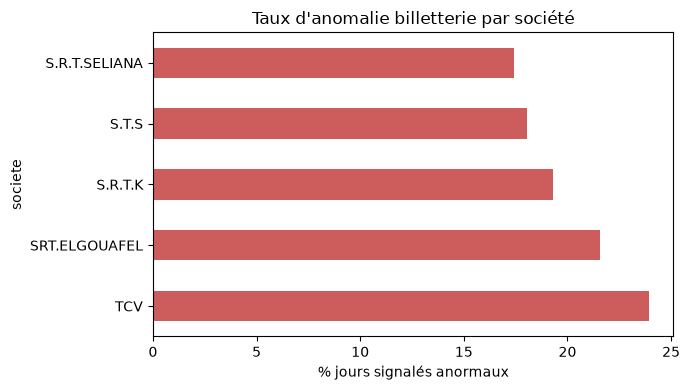

In [11]:
result = ta_model.train(conn)
days_scored = result['days']

fig, ax = plt.subplots(figsize=(7,4))
rates = days_scored.groupby('societe')['anomaly'].mean().sort_values(ascending=False) * 100
rates.plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% jours signalés anormaux'); ax.set_title("Taux d'anomalie billetterie par société")
plt.tight_layout(); plt.show()

**Interprétation :** chaque société a son propre modèle -- un jour normal pour TCV
(ligne urbaine à haute fréquence, gros volumes) n'est pas comparé à la normale de
S.R.T.SELIANA (ligne régionale, petits volumes). Le taux d'anomalie par société reflète sa
propre variance interne, pas une comparaison brute entre sociétés de tailles différentes.

In [12]:
top_anom = (days_scored[days_scored['anomaly']]
            .sort_values('if_score')
            .head(15)[['societe','line','bus','day','nbr_ticket','recette','avg_fare','if_score']])
top_anom['avg_fare'] = top_anom['avg_fare'].round(2)
top_anom['if_score'] = top_anom['if_score'].round(3)
print('Top 15 jours-bus les plus anormaux (ventes de tickets) :')
display(top_anom)

Top 15 jours-bus les plus anormaux (ventes de tickets) :


,societe,line,bus,day,nbr_ticket,recette,avg_fare,if_score
4590,TCV,4,157,20250227,544,924.80,1.70,-0.813
5050,TCV,4,176,20250519,546,928.20,1.70,-0.813
4599,TCV,4,157,20250228,528,897.60,1.70,-0.809
4516,TCV,4,157,20250217,500,850.00,1.70,-0.795
4497,TCV,4,157,20250214,477,810.90,1.70,-0.786
4413,TCV,4,157,20250203,475,807.50,1.70,-0.784
5268,TCV,4,157,20250630,462,785.40,1.70,-0.778
4583,TCV,4,157,20250226,457,776.90,1.70,-0.774
4484,TCV,4,157,20250212,456,775.20,1.70,-0.773
4600,TCV,4,173,20250228,442,751.40,1.70,-0.758


**Comment lire ce tableau :** ce sont les jours-bus les plus faciles à isoler du
comportement normal de leur société -- typiquement un volume de tickets ou une recette très
supérieure (ou inférieure) à ce que cette ligne/société vend habituellement. Une recette
anormalement BASSE avec un volume normal peut signaler une fraude/évasion tarifaire ; un
`avg_fare` très différent de la normale peut signaler une erreur de caisse.

**Action commerciale :** ces jours-bus valent une vérification manuelle contre les journaux de
caisse -- une anomalie confirmée aide à calibrer le seuil (`if_contamination` dans
`TICKET_CFG`) pour de futurs entraînements.

### Conclusions -- module billetterie

- Signal **complémentaire** au GPS, pas fusionné : grain jour-bus-ligne, pas trajet.
- Isolation Forest **par société** comme pour le GPS -- même justification (éviter qu'une
  grosse société impose sa normale aux petites).
- `if_contamination='auto'` par défaut (data-driven) -- modifiable dans `TICKET_CFG` en tête
  de section pour forcer un taux si souhaité, sans toucher au code.
- Prochaine étape naturelle : persister les scores dans une table SQL (`anomaly_scores` ou
  une variante dédiée au grain jour) pour que l'API puisse les servir, au lieu du seul
  parquet `models/ticket_anomaly/days_scored.parquet`.

## Save to production artifact (GPS anomaly module)

Sections above trained inline via `src.data.anomaly` directly, for exploration. This final
cell calls the exact same `src.models.anomaly.train()` function `src/train_pipeline.py`
calls, saving to the same `models/anomaly/` location (per-company Isolation Forest +
per-company LSTM autoencoder, with global fallback) — so running this notebook end-to-end
is a complete, equivalent alternative to running the pipeline command, not just a demo.


In [ ]:
from src.models import anomaly as anomaly_model

ROOT = Path(an.__file__).resolve().parents[2]
FOUNDATION_PATH = ROOT / "data" / "processed" / "foundation_arrivals_full.parquet"
SAVE_DIR = ROOT / "models" / "anomaly"

result = anomaly_model.train(FOUNDATION_PATH, SAVE_DIR)
print(f"n_if: {result['n_if']} n_lstm: {result['n_lstm']}")
print(f"-> Artifacts saved to {SAVE_DIR.resolve()}")
